<a href="https://colab.research.google.com/github/pooriaazami/how_to_deeply_code_2026/blob/main/DeepLearningCodeing_S1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision as tv
import torchvision.transforms as T

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

In [24]:
transforms = T.ToTensor()

# transforms = T.Compose([
#    T.ToTensor(),
#    T.Normalize((.5,), (.1,)),
#    T.RandomVerticalFlip(.2),
# ])

train_dataset = tv.datasets.MNIST(root='.', train=True, download=True, transform=transforms)
val_dataset = tv.datasets.MNIST(root='.', train=False, download=True, transform=transforms)

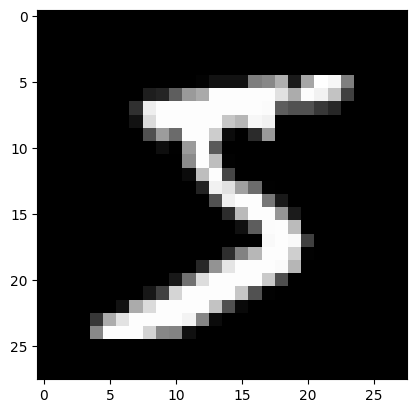

In [28]:
image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap='grey')
plt.show()

In [23]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [29]:
model = nn.Sequential(
  nn.Flatten(1),
  nn.Linear(in_features=28 * 28, out_features=128),
  nn.ReLU(),
  nn.Linear(in_features=128, out_features=128),
  nn.ReLU(),
  nn.Linear(in_features=128, out_features=10),
)

In [30]:
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)

In [31]:
x, _ = train_dataset[0]

In [37]:
preds = model(x)

preds

tensor([[ 0.0037,  0.0507,  0.0883,  0.0147,  0.0395, -0.1019,  0.0474,  0.0370,
         -0.0569,  0.0210]], grad_fn=<AddmmBackward0>)

$$ softmax(x_i) = \frac{exp(x_i)}{\sum_{j=1}^{n}{exp(x_j)}}$$

$$ log(softmax(x_i)) = log(\frac{exp(x_i)}{\sum_{j=1}^{n}{exp(x_j)}})$$

In [35]:
.1 + .2 == .3 # IEEE754

False

In [36]:
loss_fn = nn.CrossEntropyLoss()

In [42]:
loss = loss_fn(preds, torch.tensor([train_dataset[0][1]]))

loss

tensor(2.4202, grad_fn=<NllLossBackward0>)

In [40]:
preds

tensor([[ 0.0037,  0.0507,  0.0883,  0.0147,  0.0395, -0.1019,  0.0474,  0.0370,
         -0.0569,  0.0210]], grad_fn=<AddmmBackward0>)

In [41]:
torch.tensor([train_dataset[0][1]])

tensor([5])

$$ preds = f_5(f_4(f_3(f_2(f_1(x))))) $$
$$ loss = lossfn(f_5(f_4(f_3(f_2(f_1(x))))), y) $$

$$ \frac{\partial loss}{f_5}, \frac{\partial loss}{f_4}, ..., \frac{\partial loss}{f_1} $$

In [43]:
loss.backward()

In [46]:
for x in model.parameters():
  break

In [49]:
x.grad.shape

torch.Size([128, 784])

In [52]:
x.shape

torch.Size([128, 784])

In [55]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [56]:
optimizer.step()

In [70]:
total_loss = 0
preds = []
labels = []

for i, (x, y) in enumerate(tqdm(train_dataset)):
  if i == 100:
    break

  y = torch.tensor([y])

  optimizer.zero_grad()
  pred = model(x)
  loss = loss_fn(pred, y)

  loss.backward()
  optimizer.step()

  total_loss += loss.detach().cpu().item()
  preds.extend(pred.argmax(1).tolist())
  labels.extend(y.tolist())

accuracy = accuracy_score(preds, labels)

print(f'Total Loss: {total_loss:.2f}, Accuracy: {accuracy*100:.2f}')

  0%|          | 0/60000 [00:00<?, ?it/s]

Total Loss: 13.28, Accuracy: 97.00


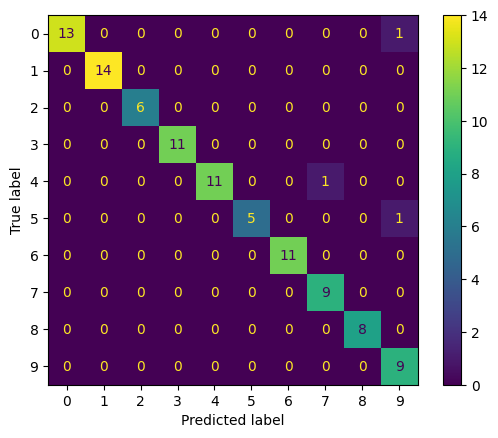

In [72]:
ConfusionMatrixDisplay.from_predictions(preds, labels)